<a href="https://colab.research.google.com/github/bongkyunSON/TIL/blob/main/SensorDataEDA_2022_09_29.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<font color=pink> ✨직장인을 위한 파이썬 데이터 분석**
<font color=pink>┗ Part3. 다양한 실무 데이터를 활용하여 실습하기
---

> **(1) 강사**
 - 박지환  

> **(2) 이력**
 - 제조, 금융, 유통 다양한 산업군에서 데이터 분석가로서 활동

> **(3) 강의 내용**
 - ① 가상 시나리오 및 데이터 현황 ② 문제해결프로세스 정의 ③ Session1~3(문제해결)

> **(4) 강의 목적**
 - "현업에서는 어떻게 데이터 분석을 수행하고, 어떻게 결과물을 만들어 낼까?"

<font color=gray>※ Tip) 도구 - 설정 > Dark mode & "저장할때 출력 생략" 해제  

<font color=gray>※ 중요) 현업에 바로 적용할 수 있는 데이터 분석 코드 가이드.pdf


# **Chapter 01**  
**┗ 센서 데이터 활용 장비 이상진단 및 예측**
---
> **목차(Context)**

* 문제상황 및 데이터 살펴보기
* 문제해결 프로세스 정의
* 🥉Session 1 - 「이상(abnormal) 정의 및 데이터 EDA」
* 🥈Session 2 - 「Rule base 이상진단」
* 🥇Session 3 - 「ML 활용 이상진단 및 예측」

In [1]:
# ▶ Warnings 제거
import warnings
warnings.filterwarnings('ignore')

# ▶ Google drive mount or 폴더 클릭 후 구글드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

# ▶ 경로 설정 (※ Colab을 활성화시켰다면 보통 Colab Notebooks 폴더가 자동 생성)


Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/online/python/park2/chapter01_센서 데이터 활용 장비 이상진단 및 예측')
# '/content/drive/MyDrive/Colab Notebooks/ ← 여기 경로까지는 본인의 경로 입력, part3_lecture_fastcampus/chapter01' ← 변경X
os.getcwd()

'/content/drive/MyDrive/online/python/park2/chapter01_센서 데이터 활용 장비 이상진단 및 예측'

## **문제상황 및 데이터 살펴보기**
---
> **시나리오** 👷 (제품설계자, 장비 오퍼레이터)

```
A공장에서는 최근 도입한 장비로 인하여 골치를 썩고 있다. 새로 도입한 장비의 지속적인 고장으로 인하여 생산 스케줄을 지연되고  
있기 때문이다. 해당 장비의 특성상 한 번 고장이 나면 라인 전체를 Stop 시켜야 하므로 공정 Process에서 Bottleneck 구간이다.  
고장이 나면 공정상 막대한 손해이기 때문에 고장이 나기 전 사전 이상징후를 포착하고 점검을 통해 고장이 발생하여 미치는
손실을 줄이고자 한다.
```  

> **데이터 살펴보기**

* 장비의 이상징후를 포착하기 위해 장비의 특정 위치의 충돌 센서 4개(S1~S4)를 설치하였다.
* 센서 특정 위치에 충돌이 일어나면 최종적으로 충돌 당시의 M(질량)과 V(속도)가 기록된다.
* 장비에 특정 이상의 충격(M*V)이 가해지면 장비는 정지하게 된다.


In [3]:
# ▶ Data read
import pandas as pd
df_features = pd.read_csv('/content/drive/MyDrive/online/python/park2/chapter01_센서 데이터 활용 장비 이상진단 및 예측/chapter01_abnormal_features.csv')
df_target = pd.read_csv('/content/drive/MyDrive/online/python/park2/chapter01_센서 데이터 활용 장비 이상진단 및 예측/chapter01_abnormal_target.csv')

In [4]:
df_features.head()

,id,Time,S1,S2,S3,S4
0,0,0.000000,0.0,0.0,0.0,0.0
1,0,0.000004,0.0,0.0,0.0,0.0
2,0,0.000008,0.0,0.0,0.0,0.0
3,0,0.000012,0.0,0.0,0.0,0.0
4,0,0.000016,0.0,0.0,0.0,0.0


In [5]:
df_target.head()

,id,X,Y,M,V
0,0,0.0,-400.0,50.0,0.4
1,1,400.0,0.0,100.0,1.0
2,2,-300.0,-200.0,25.0,0.4
3,3,200.0,-100.0,150.0,0.4
4,4,-300.0,-100.0,150.0,0.4


* df_features Data set에는 'Time' 시간 별 센서에서 수집되고 있는 S1~S4 값이 수집된다.
* df_target에는 장비에 최종적으로 전달된 M(질량)과 속도(V)가 기록되어 있다.

## **문제해결 프로세스 정의**
---
> **문제정의**

```
▶ 설비 고장으로 인한 Line stop, 생산 스케줄 지연, 매출감소, 영업이익 감소
```  

> **기대효과**

```
▶ 사전 이상징후 감지 및 점검을 통해 고장으로 인한 Line stop 감소, 생산 스케줄 정상화
```

> **해결방안**

```
▶ 데이터 기반으로 이상징후를 정의하고, 센서 데이터 모니터링을 통해 이상징후 포착 및 실시간 점검
▶ Session 1 🥉
 - 고장이 발생하기 전 이상 증상에 대한 정의  
▶ Session 2 🥈
 - 현업의 노하우, 경험적 지식에 기반한 Rule base 이상진단
▶ Session 3 🥇
 - 모델링을 통한 이상 증상 예측 

```

> **성과측정**  

```
▶ 이상징후 모니터링 전/후 제품 생산량, Line stop 횟수 비교
```

> **현업적용**  

```
▶ 실시간 센서 데이터 수집 및 DB 적재 시스템 구축  
▶ Server에 데이터 모델 탑재 및 특정 시간 단위 실행 및 결과 저장  
▶ 결과 데이터 대시보드 및 BI 시스템에 출력 및 모니터링
```

> **주요 코드 미리 살펴보기**  

```
▶ session 1 → unique(), value_counts()
▶ session 2 → sns.scatterplot(), plt.axhline(), np.where
▶ session 3 → RandomForestClassifier, classification_report, GridSearchCV
```

## **🥉Session 1**  
**┗ 이상(abnormal)정의 및 데이터 EDA**  
---


### · Data 전처리  
---
* 수집된 데이터의 기본 정보들을 확인  

  (1) Data shape(형태) 확인 

  (2) Data type 확인

  (3) Null값 확인 (※ 빈 값의 Data)

  (4) Outlier 확인 (※ 정상적인 범주를 벗어난 Data)  


In [6]:
# ▶ Data 형태 확인
# ▶ feature data의 row의 개수와 target data의 row 개수가 다름 
print('df_features', df_features.shape)
print('df_target', df_target.shape)

df_features (1050000, 6)
df_target (2800, 5)


In [7]:
# ▶ Data type 확인
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   id      1050000 non-null  int64  
 1   Time    1050000 non-null  float64
 2   S1      1050000 non-null  float64
 3   S2      1050000 non-null  float64
 4   S3      1050000 non-null  float64
 5   S4      1050000 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 48.1 MB


In [8]:
# ▶ data 정보확인
df_target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      2800 non-null   int64  
 1   X       2800 non-null   float64
 2   Y       2800 non-null   float64
 3   M       2800 non-null   float64
 4   V       2800 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 109.5 KB


In [9]:
# ▶ Null 값 확인
# print(df_features.isnull().sum())
# print('')
# print(df_target.isnull().sum())


print(df_features.isnull().sum())
print('')
print(df_target.isnull().sum())

id      0
Time    0
S1      0
S2      0
S3      0
S4      0
dtype: int64

id    0
X     0
Y     0
M     0
V     0
dtype: int64


In [10]:
# ▶ Unique한 ID 개수 확인
# ▶ Unique한 ID 개수가 동일한 것으로 보아, Feature data가 id당 다수의 데이터를 가지고 있는 것으로 추정
# print('df_features_unique_id :', len(df_features['id'].unique()))
# print('df_target_unique_id :', len(df_target['id'].unique()))

print('df_features_unique_id :', len(df_features['id'].unique()))
print('df_target_unique_id :', len(df_target['id'].unique()))

df_features_unique_id : 2800
df_target_unique_id : 2800


In [11]:
# ▶ 하나의 ID(제품)당 0.000004초의 간격으로 센서 S1~S4에 값이 수집되고 있는 상황
# df_features[df_features['id']==0].head(5)

df_features[df_features['id']==0]

,id,Time,S1,S2,S3,S4
0,0,0.000000,0.00,0.00,0.00,0.000
1,0,0.000004,0.00,0.00,0.00,0.000
2,0,0.000008,0.00,0.00,0.00,0.000
3,0,0.000012,0.00,0.00,0.00,0.000
4,0,0.000016,0.00,0.00,0.00,0.000
...,...,...,...,...,...,...
370,0,0.001480,-64168.90,-64168.90,52279.59,106792.600
371,0,0.001484,-64236.79,-64236.79,16518.64,58248.420
372,0,0.001488,-63755.95,-63755.95,-25270.30,3015.649
373,0,0.001492,-63020.44,-63020.44,-65904.66,-49795.140


In [12]:
# ▶ Target data set과 차원을 맞춰주기 위해 id 별로 Sensor 값의 평균(mean)을 사용
# ▶ Data를 그룹핑 하는 방법에는 다양한 방법이 있으나, 현업에서 의미있는 방법으로 데이터를 그룹핑 하는 것을 추천
# df_features_proc = df_features.groupby('id').mean()

df_features_proc = df_features.groupby('id').mean()

In [13]:
df_features.groupby('id').mean()

# df_features_proc

,Time,S1,S2,S3,S4
id,,,,,
0,0.000748,-308.304553,-308.304553,1119.504719,1410.502893
1,0.000748,12780.176893,981.778780,7953.031214,-15584.755221
2,0.000748,-674.289628,-1575.681938,137.430228,-407.092340
3,0.000748,2164.216981,-11274.728589,-4221.738240,5241.350867
4,0.000748,-980.480585,-6966.912566,-2555.746810,5596.931287
...,...,...,...,...,...
2795,0.000748,5600.614397,5885.824925,-6380.192826,-7357.437798
2796,0.000748,-1215.328099,2702.879683,805.983784,-2876.150150
2797,0.000748,436.239993,276.327514,951.805606,-903.193922


In [14]:
print('df_features', df_features_proc.shape)
print('df_target', df_target.shape)

df_features (2800, 5)
df_target (2800, 5)


In [15]:
# ▶ Data left join
# df_merge = pd.merge(df_features_proc, df_target, on='id',how='left')

df_merge = pd.merge(df_features_proc, df_target, on='id', how='left')

In [16]:
df_merge.head(5)

,id,Time,S1,S2,S3,S4,X,Y,M,V
0,0,0.000748,-308.304553,-308.304553,1119.504719,1410.502893,0.0,-400.0,50.0,0.4
1,1,0.000748,12780.176893,981.778780,7953.031214,-15584.755221,400.0,0.0,100.0,1.0
2,2,0.000748,-674.289628,-1575.681938,137.430228,-407.092340,-300.0,-200.0,25.0,0.4
3,3,0.000748,2164.216981,-11274.728589,-4221.738240,5241.350867,200.0,-100.0,150.0,0.4
4,4,0.000748,-980.480585,-6966.912566,-2555.746810,5596.931287,-300.0,-100.0,150.0,0.4


In [17]:
# ▶ 전처리 완료된 최종 Data set
# df_merge=df_merge.drop(['Time', 'X', 'Y'], axis=1)
# df_merge.head(5)


df_merge = df_merge.drop(['Time', 'X', 'Y'], axis=1)
df_merge

,id,S1,S2,S3,S4,M,V
0,0,-308.304553,-308.304553,1119.504719,1410.502893,50.0,0.4
1,1,12780.176893,981.778780,7953.031214,-15584.755221,100.0,1.0
2,2,-674.289628,-1575.681938,137.430228,-407.092340,25.0,0.4
3,3,2164.216981,-11274.728589,-4221.738240,5241.350867,150.0,0.4
4,4,-980.480585,-6966.912566,-2555.746810,5596.931287,150.0,0.4
...,...,...,...,...,...,...,...
2795,2795,5600.614397,5885.824925,-6380.192826,-7357.437798,50.0,1.0
2796,2796,-1215.328099,2702.879683,805.983784,-2876.150150,150.0,0.2
2797,2797,436.239993,276.327514,951.805606,-903.193922,50.0,0.2
2798,2798,-2394.515047,6230.349355,-8365.334186,-6421.442031,125.0,0.6


### · 이상(abnormal) 정의
---
* 장비가 고장나기 전에 사전 점검을 하기 위한 이상(abnormal) 현상을 정의
* 장비가 이상(abnormal)에 도달 시 사전 점검을 하기 위함

In [18]:
# ▶ 위에서 정의한 것처럼 M(질량) X V(속도) = 최종 충돌 에너지로 정의하고, 새로운 Col을 생성
# df_merge['MV'] = df_merge['M'] * df_merge['V']
# df_merge.head(5)

df_merge['MV'] = df_merge['M'] * df_merge['V']
df_merge

,id,S1,S2,S3,S4,M,V,MV
0,0,-308.304553,-308.304553,1119.504719,1410.502893,50.0,0.4,20.0
1,1,12780.176893,981.778780,7953.031214,-15584.755221,100.0,1.0,100.0
2,2,-674.289628,-1575.681938,137.430228,-407.092340,25.0,0.4,10.0
3,3,2164.216981,-11274.728589,-4221.738240,5241.350867,150.0,0.4,60.0
4,4,-980.480585,-6966.912566,-2555.746810,5596.931287,150.0,0.4,60.0
...,...,...,...,...,...,...,...,...
2795,2795,5600.614397,5885.824925,-6380.192826,-7357.437798,50.0,1.0,50.0
2796,2796,-1215.328099,2702.879683,805.983784,-2876.150150,150.0,0.2,30.0
2797,2797,436.239993,276.327514,951.805606,-903.193922,50.0,0.2,10.0
2798,2798,-2394.515047,6230.349355,-8365.334186,-6421.442031,125.0,0.6,75.0


충돌에너지 평균 : 60.0


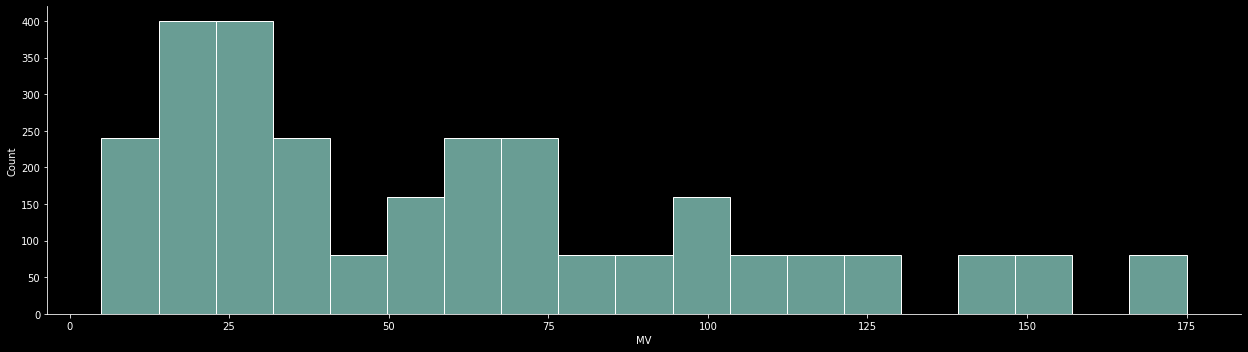

In [22]:
from ast import increment_lineno
# ▶ 이상(abnormal)을 정의하기 위해 MV(충돌 에너지)의 분포를 확인
# ▶ 대다수의 충돌에너지 data가 충돌에너지의 평균인 60선에 분포
# import matplotlib.pyplot as plt
# import seaborn as sns
# %matplotlib inline
# plt.style.use(['dark_background'])

# sns.displot(df_merge['MV']);
# plt.gcf().set_size_inches(20, 5)
# print("충돌에너지 평균 :", df_merge['MV'].mean())



import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use(['dark_background'])


# plt.figure(figsize = (50,3))
# sns.displot(df_merge['MV'])
# print("충돌에너지 평균 :", df_merge['MV'].mean())
# plt.show()


sns.displot(df_merge['MV'])
plt.gcf().set_size_inches(20, 5)
print("충돌에너지 평균 :", df_merge['MV'].mean())

## **정리**
---

```
- plt.gcf로 가로축을 길게 그래프 그리는걸 새롭게 알게됨 항상 plt.figure(figsize=(8, 6))로 했는데 새롭게 알게되어서 좋았음
- head와 tail을 나는 안쓰고 그냥 데이터 자체를 불러오는걸 좋아함 그럼 columns와 rows를 볼수있어서 개인적인 취향은 그러함, 여기 강사님은 특이하게 head(5) 넣어서 사용함 5개는 기본값인데...특이하네